*TP - M2MO - 2025/2026*

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import torch
from torch import nn 

# Necessary baby-steps before writing a neural network

The `torch.nn.Module` class is a fundamental building block in PyTorch that serves as a base class for all neural network modules. It provides a convenient way to organize and encapsulate all the learnable parameters (i.e., weights and biases) and operations of a neural network in one place.

The main purpose of the `torch.nn.Module` class is to define the architecture of a neural network and specify how input data should flow through the network to produce an output. It provides methods for defining the parameters of the network, initializing the parameters, and performing forward and backward passes through the network.

Additionally, the `torch.nn.Module` class provides several helpful methods for managing the state of the network, such as `.train()` and `.eval()` for setting the network to training or evaluation mode (essential for `BatchNorm` for example), and `.parameters()` for accessing the learnable parameters of the network.

By subclassing this class and implementing the `forward()` method, you can define complex neural network architectures and use them for a wide range of machine learning tasks.

Write a subclass of `torch.nn.Module` to represent a simple linear model that predicts a real-valued output variable $y = w^{\top}x$ given a vector-valued input variable $x$, where $w$ is the vector of weights of the linear model. The dimension `dim` of $x$, which will also be the number of weights in $w$, is expected to be passed as a parameter to the constructor of your subclass.

Implement the `forward` method of your model to define how the input data should flow through the model to produce an output. Implement it while assuming that the input `x` is a row vector.

In [ ]:

#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
class LinearRegression(torch.nn.Module):
    def __init__(self, x_dim : int):
      super().__init__()
      temp_w = torch.randn(x_dim, dtype = torch.float32)
      self.w = nn.Parameter(temp_w)

    def forward(self, x):
      return x @ self.w


Test your model on some example input data to verify that it produces the expected output.

In [18]:
x = torch.randn(50)
module = LinearRegression(50)
module(x)
list[module.w]

list[Parameter containing:
tensor([-1.6214,  0.0535, -0.2955, -1.5205,  0.8269, -0.4391,  0.5324,  0.4857,
        -1.6652,  0.0521,  1.3414,  0.4025, -0.8920,  0.0146,  0.6837, -1.9965,
        -1.4076,  0.0473, -0.8838,  1.6883, -0.4802, -0.5911, -1.2162,  0.5208,
        -1.1276,  1.6166,  1.5177, -0.2420,  0.9605, -0.0829, -0.4771,  0.3721,
        -1.1809, -0.4122, -1.6473, -0.7160, -0.1412,  0.9731, -0.8195, -0.2567,
         0.0692, -1.6270, -0.2868, -1.5792, -2.4500,  0.3130, -0.4183,  2.5012,
         0.4624,  0.8374], requires_grad=True)]

Using the `LinearRegression` model that you implemented, create some dummy data consisting of 2000 samples, where each sample has an input of dimension 5 and an output of dimension 1.

Split your data evenly into a training set and a validation set.

Define a mean squared error (MSE) loss function and a stochastic gradient descent (SGD) optimizer with a learning rate of 0.01.

Train the model on the training set for 3000 epochs, and after each epoch, evaluate the model on the validation set and print the loss. Plot the training loss and validation loss over time to visualize the training progress.

In [28]:
# Create "reference" weights which we will forget about once we generate linear data

# Generate some dummy data

# Split the data evenly into training and validation sets
x_dim = 5
n = 2000

w_ref = torch.randn(x_dim)

dummy_data_x = torch.randn((n, x_dim))
dummy_data_y = dummy_data_x @ w_ref

dummy_data_x_train, dummy_data_x_evaluate = dummy_data_x[:1000, :], dummy_data_x[1000:,:]
dummy_data_y_train, dummy_data_y_evaluate = dummy_data_y[:1000], dummy_data_y[1000:]


In [95]:
# Define the model, loss function, and optimizer
model = LinearRegression(x_dim)
def MSE(y_pred, y_true): 
    l = (y_pred - y_true)**2
    return l.mean()

optim = torch.optim.SGD(params = model.parameters(), lr = .01)



In [30]:
# training code

epochs = 3000
for epoch in range(epochs):
    y_pred = model(dummy_data_x_train)
    loss = MSE(y_pred, dummy_data_y_train)
    optim.zero_grad()
    loss.backward()
    print(model.w.grad)
    optim.step()
    loss_val = MSE(model(dummy_data_x_evaluate), dummy_data_y_evaluate)
    print(f"Epoch {epoch+1} | Train Loss = {loss} | Val Loss = {loss_val}")

tensor([-3.1052, -2.1891,  3.2704,  0.6698,  0.7466])
Epoch 1 | Train Loss = 6.414392471313477 | Val Loss = 6.397324562072754
tensor([-3.0405, -2.1428,  3.2057,  0.6599,  0.7290])
Epoch 2 | Train Loss = 6.155697345733643 | Val Loss = 6.13992166519165
tensor([-2.9771, -2.0975,  3.1423,  0.6500,  0.7119])
Epoch 3 | Train Loss = 5.9074602127075195 | Val Loss = 5.892899513244629
tensor([-2.9150, -2.0531,  3.0802,  0.6403,  0.6951])
Epoch 4 | Train Loss = 5.669257640838623 | Val Loss = 5.65583610534668
tensor([-2.8542, -2.0097,  3.0193,  0.6307,  0.6787])
Epoch 5 | Train Loss = 5.440682411193848 | Val Loss = 5.428329944610596
tensor([-2.7947, -1.9672,  2.9595,  0.6213,  0.6627])
Epoch 6 | Train Loss = 5.221344947814941 | Val Loss = 5.209995269775391
tensor([-2.7365, -1.9256,  2.9010,  0.6119,  0.6471])
Epoch 7 | Train Loss = 5.010869979858398 | Val Loss = 5.000461101531982
tensor([-2.6795, -1.8849,  2.8436,  0.6027,  0.6318])
Epoch 8 | Train Loss = 4.808899402618408 | Val Loss = 4.799371242

As a sanity check, now compare the *groundtruth* weights you used to generate the data, and the weights estimated by your training routine. Both should be roughly close.

In [31]:
diff_w = torch.abs(torch.max(model.w - w_ref))

print(f"Différence L infty entre les poids :{diff_w} ")


Différence L infty entre les poids :2.7418136596679688e-06 


# Pricing using a neural network

Write a function `generate_S0_callpayoff(N, K, T, r, sigma)` which generates `N` samples from the pair $\left(S_0, e^{-r T}\left(S_T-K\right)^+\right)$. The function should return two `numpy` arrays of shape `(N,1)`, one for $S_0$ and the other for the call payoff, where the $i$-th row represents the $i$-th sample. Assume $S_0 \sim \mathcal{U}\left(\left[10,200\right]\right)$ and that conditional on $S_0$, $\left(S_t\right)_t$ has Black-Scholes dynamics with drift $r$ (`r`) and vol $\sigma$ (`sigma`).

In [108]:
def generate_S0_callpayoff(N, K, T, r, sigma):
    S_0 = np.random.uniform(10, 200, N+1)
    S_T  = S_0 * np.exp( (r-1/2 *sigma**2)*T)
    eps = np.random.standard_normal(N+1)
    S_T = S_T * np.exp(np.sqrt(T)*sigma*eps)
    call_payoff = np.exp(-r*T)* np.maximum(S_T - K, 0)
    return S_0, call_payoff



Generate 100000 samples for training and 100000 samples for validation.
Take $K=102.5$, $T=1.5$, $r=2.5\%$ and $\sigma=30\%$.

In [116]:
N = 100000
K = 102.5
T = 1.5
r = .025
sigma = .3

training_sample_x, training_sample_y = generate_S0_callpayoff(N, K, T, r, sigma)
validation_sample_x, validation_sample_y = generate_S0_callpayoff(N, K, T, r, sigma)
training_sample_x = torch.from_numpy(training_sample_x).reshape((-1,1))
training_sample_y = torch.from_numpy(training_sample_y).reshape((-1,1))
validation_sample_x = torch.from_numpy(validation_sample_x).reshape((-1,1))
validation_sample_y = torch.from_numpy(validation_sample_y).reshape((-1,1))


## Normaliser les valeurs 
training_sample_x_n = (training_sample_x - training_sample_x.mean())/training_sample_x.std()
training_sample_y_n = (training_sample_y - training_sample_y.mean())/training_sample_y.std()

validation_sample_x_n = (validation_sample_x - validation_sample_x.mean())/validation_sample_x.std()
validation_sample_y_n = (validation_sample_y - validation_sample_y.mean())/validation_sample_y.std()


Your task now is to implement a feedforward neural network with two hidden layers, each with 15 neurons and sigmoid activations. The input and output dimensions should both be equal to 1.

The neural network should output $y = W_{out} \varphi\left(W_2 \varphi\left(W_1 x + b_1\right) + b_2\right)+b_{out}$ for a given input $x$, where $\varphi : u \mapsto \frac{1}{1+e^{-u}}$ is the sigmoid activation function applied element-wise on vector inputs, $W_1$, $W_2$ and $W_{out}$ are respectively $15\times 1$, $15\times 15$ and $1\times 15$ weight matrices, and $b_1, b_2 \in \mathbb{R}^{15}$ and $b_{out} \in \mathbb{R}$ are biases. For better numerical stability, use `torch.sigmoid` instead of implementing the activation function yourself (otherwise you will have to deal with overflow issues because of the exponential).

$W_1$, $W_2$, $W_{out}$, $b_1$, $b_2$ and $b_{out}$ are the parameters of the neural network, to be estimated later during training.

Make sure that the initial values of the weight matrices are such that each weight of a given layer is normally distributed with mean $0$ and variance $\frac{2}{n_{in}+n_{out}}$ where $n_{in}$ and $n_{out}$ and the input and output dimensions of the layer.

The biases on the other hand can be initialized to zero.

In [110]:
class PricingNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.w1 = nn.Parameter(torch.normal(0, 1/8, size =(1,15) , dtype = float))
        self.b1 = nn.Parameter(torch.zeros(15))
        self.w2 = nn.Parameter(torch.normal(0, 1/15, size =(15,15), dtype = float ))
        self.b2 = nn.Parameter(torch.zeros(15))
        self.w_out = nn.Parameter(torch.normal(0, 1/8, size =(15,1), dtype = float))
        self.b_out = nn.Parameter(torch.zeros(1))
    def forward(self, x): 
        step = x @self.w1 + self.b1
        step = torch.sigmoid(step)
        step = step@self.w2 + self.b2
        step = torch.sigmoid(step)
        step = step@self.w_out + self.b_out
        return step

Define a mean squared error (MSE) loss function and an Adam optimizer with a learning rate of 0.01.

Train your neural network on your dataset, assuming the input/output pairs are $S_0$ and the discounted payoff, for 2500 epochs, and after each epoch, evaluate the neural network on the validation set and print the loss. Plot the training loss and validation loss over time to visualize the training progress.

In [ ]:
## MSE : on use a nouveau de la mse du code précédent


model = PricingNN(1)
optim = torch.optim.Adam(model.parameters(), lr = .01)
# training code
loss_ = []
loss_val_ = []
epochs = 2000
for epoch in range(epochs):
    y_pred = model(training_sample_x_n)
    loss = MSE(y_pred, training_sample_y_n)
    loss_.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()
    loss_val = MSE(model(validation_sample_x_n), validation_sample_y_n)
    loss_val_.append(loss_val.item())
    print(f"Epoch {epoch+1} | Train Loss = {loss} | Val Loss = {loss_val}")


Epoch 1 | Train Loss = 0.9990686796931234 | Val Loss = 1.0048391135043615
Epoch 2 | Train Loss = 1.0048620296449027 | Val Loss = 0.9967018110528731
Epoch 3 | Train Loss = 0.9967311672333812 | Val Loss = 0.9991993021369382
Epoch 4 | Train Loss = 0.9992383723135004 | Val Loss = 0.9986848615436233
Epoch 5 | Train Loss = 0.9987353507181502 | Val Loss = 0.9944959226772817
Epoch 6 | Train Loss = 0.9945578584820411 | Val Loss = 0.9916762195485366
Epoch 7 | Train Loss = 0.991750309214495 | Val Loss = 0.9912777152039596
Epoch 8 | Train Loss = 0.9913659032980745 | Val Loss = 0.9905176287898879
Epoch 9 | Train Loss = 0.9906225851099795 | Val Loss = 0.9877392357143178
Epoch 10 | Train Loss = 0.9878636680611181 | Val Loss = 0.9840253003828837
Epoch 11 | Train Loss = 0.9841720218560236 | Val Loss = 0.9808686993039922
Epoch 12 | Train Loss = 0.9810408776722702 | Val Loss = 0.9784040878414715
Epoch 13 | Train Loss = 0.9786052513278336 | Val Loss = 0.975536310363422
Epoch 14 | Train Loss = 0.9757701323

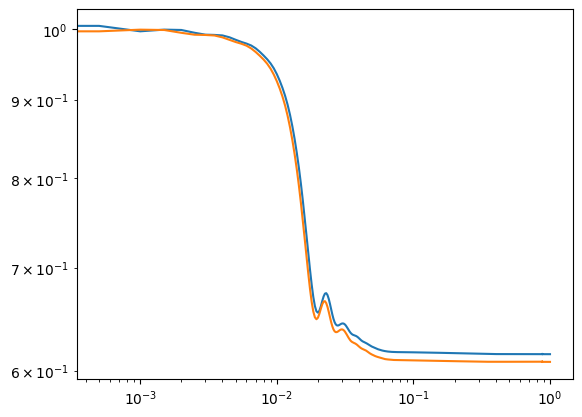

In [127]:
e = np.linspace(0,1, 2000)
plt.figure()
plt.loglog(e, loss_)
plt.loglog(e, loss_val_)
plt.show()

Make a scatter plot of the predictions of the network against $S_0$ on your test set. In the same plot, plot the price of the considered call as a function of $S_0$ and also the discounted payoffs against $S_0$. (for the discounted payoffs against $S_0$, perhaps limit yourself to the first $1000$ points of the test test otherwise the plot will be too crowded).

In [137]:
S0_val = training_sample_x
ynn = model(training_sample_x_n).detach().numpy()

d1 = (torch.log(S0_val/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
price = S0_val.numpy()*stats.norm.cdf(d1.numpy())-np.exp(-r*T)*K*stats.norm.cdf(d2.numpy())

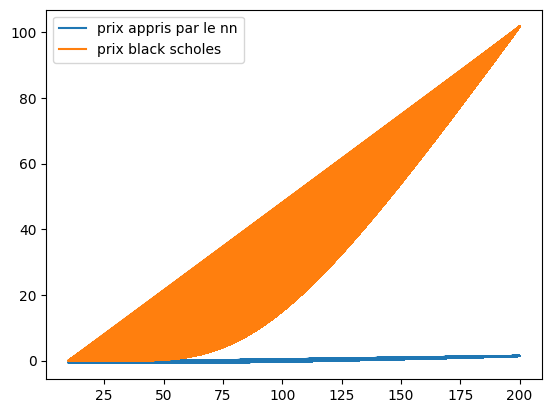

In [139]:
plt.figure()
plt.plot(S0_val, ynn, label = 'prix appris par le nn' )
plt.plot(S0_val, price, label = 'prix black scholes')
plt.legend()
plt.show()

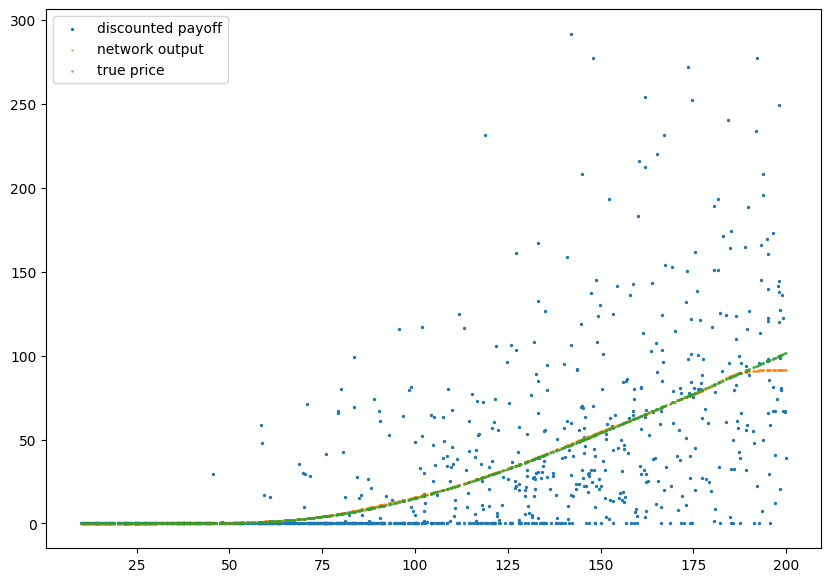

Propose an explanation for what is shown on the plots.

**Exercise:** Using the same approach, implement now a neural network to approximate the Black-Scholes price as a function of $S_0$, $r$, and $\sigma$ for fixed $K$ and $T$.

# Learning a conditional quantile

Write a function `generate_S0_ST(N, K, T, r, sigma)` which generates `N` samples from the pair $\left(S_0, S_T\right)$. The function should return two `numpy` arrays of shape `(N,1)`, one for $S_0$ and the other for $S_T$, where the $i$-th row represents the $i$-th sample. Assume $S_0 \sim \mathcal{U}\left(\left[10,200\right]\right)$ and that conditional on $S_0$, $\left(S_t\right)_t$ has Black-Scholes dynamics with drift $r$ (`r`) and vol $\sigma$ (`sigma`).

Generate 100000 samples for training and 100000 samples for validation.
Take $K=102.5$, $T=1.5$, $r=2.5\%$ and $\sigma=30\%$.

Define a "pinball" loss function corresponding to the quantile level $97.5\%$ and an Adam optimizer with a learning rate of 0.01.

Using the same architecture as previously, train your neural network on your dataset, assuming the input/output pairs are $S_0$ and $S_T$, for 2000 epochs, and after each epoch, evaluate the neural network on the validation set and print the loss. Plot the training loss and validation loss over time to visualize the training progress.

Make a scatter plot of the predictions of the network against $S_0$ on your test set. In the same plot, plot the exact 97.5% quantile of $S_T$ conditional on $S_0$ as a function of $S_0$ and plot also the realizations of $S_T$. (for the discounted payoffs against $S_0$, perhaps limit yourself to the first $1000$ points of the test test otherwise the plot will be too crowded).

# Learning a CVA

We will consider a simplified setting where a bank has only one counterparty with which it has a forward contract with maturity $T$ and delivery price $K$. The bank is supposed to be long of the contract, and the underlying is assumed to follow the following Black-Scholes dynamics:
$$d\,S_t = r S_t d\,t + \sigma S_t d\,W_t$$

We then have the following simplified definition of the CVA in this setting, assuming zero recovery:
$$\widehat{\mathrm{CVA}}_{t} := \mathbb{E}\left[e^{-r\left(\tau - t\right)} V_{\tau}^+ \mathbb{1}_{\left\{\tau \leq T\right\}}\left|\mathcal{F}_t, \left\{\tau > t\right\}\right.\right] \mathbb{1}_{\left\{\tau > t\right\}} \qquad \text{(I)}$$
where $V_t := \mathbb{E}\left[e^{-r\left(T - t\right)}\left(S_T - K\right)\left|\mathcal{F}_t\right.\right] = S_t - e^{-r\left(T - t\right)} K$ is the value of the forward contract at time $t$ from the point of view of the bank and $\tau$ is the default time of the counterparty.

We then have:

$$\widehat{\mathrm{CVA}}_{t} = \mathbb{E}\left[\int_t^T e^{-r\left(s - t\right)} \left(S_{s} - e^{-r\left(T - s\right)} K\right)^+ d \mathbb{P}\left[\tau \leq s \left| \tau > t\right.\right]\left|\mathcal{F}_t\right.\right] \mathbb{1}_{\left\{\tau > t\right\}}$$

If we consider the simple case where $\tau$ is driven by a deterministic constant default intensity $\gamma > 0$, ie $\tau \leq t \Leftrightarrow \epsilon \leq \gamma t$, then:

$$\widehat{\mathrm{CVA}}_{t} := \gamma \left( \int_t^T e^{-r\left(s - t\right)} \mathrm{C_{BS}}\left(t, S_t, e^{-r\left(T - s\right)} K, s\right) \left(1 - e^{-\gamma \left(s - t\right)}\right) d\,s \right) \mathbb{1}_{\left\{\tau > t\right\}} \qquad \text{(II)}$$

where $\mathrm{C_BS}\left(t, u, v, w\right)$ is the Black-Scholes price at time $t$ for a call option on the same underlying as our forward contract, assuming a spot price of the underlying of $u$, a strike $v$ and a maturity $w$.

Which could then be computed by numerical integration over a discrete time grid $0 = t_0 < t_1 < \dots < t_n = T$.

**(1)**: After writing the necessary simulation code for the underlying and the default time, approximate the CVA at the discrete time grid by learning directly the conditional expectation in $\text{(I)}$. You can safely assume that in that expectation, conditioning by $\mathcal{F}_t$ is the same as conditioning by $S_t$. You might prefer to work directly in discretized time to get an easier to learn expression for $\text{(I)}$ without exploiting what we know about the distribution of $\tau$.

**(2)**: Check your results against the expression in $\text{(II)}$ which requires no conditional expectation learning.

In [5]:
fig, ax = plt.subplot()
help(ax.set_ylim)

NameError: name 'ax' is not defined